In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    roc_auc_score
)

print("Libraries Imported Successfully")

Libraries Imported Successfully


In [2]:

# Load Dataset


data = load_breast_cancer()

X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target)

print("Dataset Shape :", X.shape)

print("\nFirst Five Rows\n")
display(X.head())

print("\nTarget Values")
print(y.value_counts())


# Missing Values


print("\nMissing Values")
print(X.isnull().sum())


# Train Test Split


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


# Standardization


scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("\nData Preprocessing Completed")

Dataset Shape : (569, 30)

First Five Rows



,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678



Target Values
1    357
0    212
Name: count, dtype: int64

Missing Values
mean radius                0
mean texture               0
mean perimeter             0
mean area                  0
mean smoothness            0
mean compactness           0
mean concavity             0
mean concave points        0
mean symmetry              0
mean fractal dimension     0
radius error               0
texture error              0
perimeter error            0
area error                 0
smoothness error           0
compactness error          0
concavity error            0
concave points error       0
symmetry error             0
fractal dimension error    0
worst radius               0
worst texture              0
worst perimeter            0
worst area                 0
worst smoothness           0
worst compactness          0
worst concavity            0
worst concave points       0
worst symmetry             0
worst fractal dimension    0
dtype: int64

Data Preprocessing Completed


========== Logistic Regression ==========

Accuracy : 0.9736842105263158

Precision : 0.9722222222222222
Recall : 0.9859154929577465
F1 Score : 0.9790209790209791

Classification Report

              precision    recall  f1-score   support

           0       0.98      0.95      0.96        43
           1       0.97      0.99      0.98        71

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



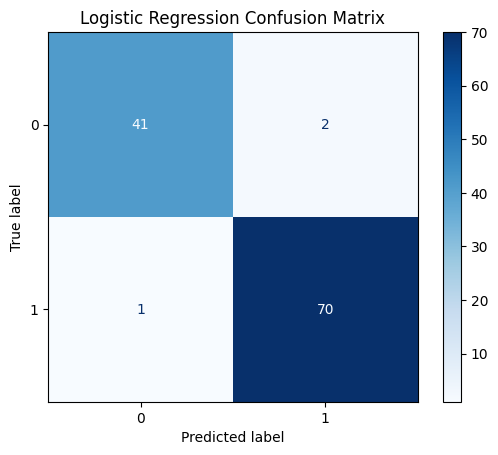

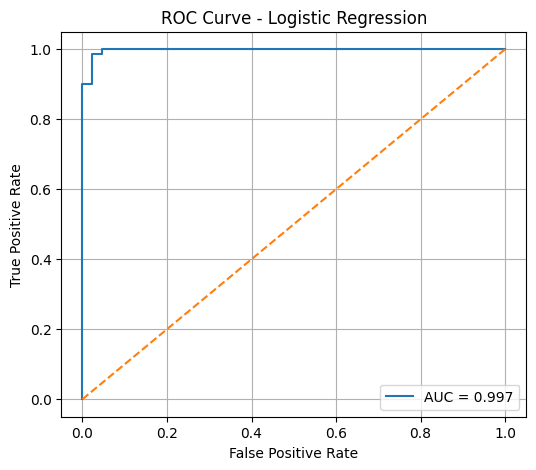

In [3]:

# Logistic Regression


log_model = LogisticRegression(max_iter=500)

log_model.fit(X_train, y_train)

y_pred_log = log_model.predict(X_test)

y_prob_log = log_model.predict_proba(X_test)[:,1]

# Evaluation


print("========== Logistic Regression ==========\n")

print("Accuracy :", accuracy_score(y_test, y_pred_log))

print("\nPrecision :", precision_score(y_test,y_pred_log))

print("Recall :", recall_score(y_test,y_pred_log))

print("F1 Score :", f1_score(y_test,y_pred_log))

print("\nClassification Report\n")

print(classification_report(y_test,y_pred_log))

# Confusion Matrix


cm = confusion_matrix(y_test,y_pred_log)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot(cmap="Blues")

plt.title("Logistic Regression Confusion Matrix")

plt.show()


# ROC Curve


fpr,tpr,_ = roc_curve(y_test,y_prob_log)

auc = roc_auc_score(y_test,y_prob_log)

plt.figure(figsize=(6,5))

plt.plot(fpr,tpr,label=f"AUC = {auc:.3f}")

plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve - Logistic Regression")

plt.legend()

plt.grid()

plt.show()

========== Decision Tree ==========

Accuracy : 0.9473684210526315

Precision : 0.9577464788732394
Recall : 0.9577464788732394
F1 Score : 0.9577464788732394

Classification Report

              precision    recall  f1-score   support

           0       0.93      0.93      0.93        43
           1       0.96      0.96      0.96        71

    accuracy                           0.95       114
   macro avg       0.94      0.94      0.94       114
weighted avg       0.95      0.95      0.95       114



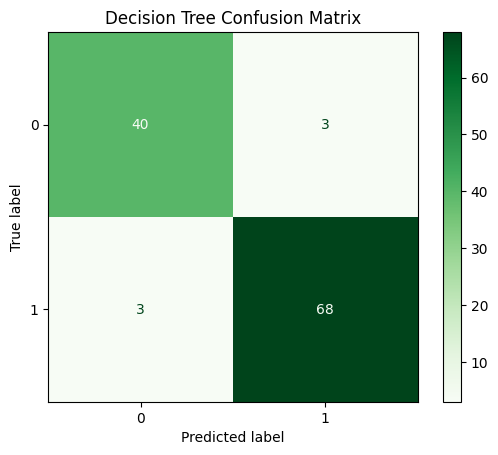

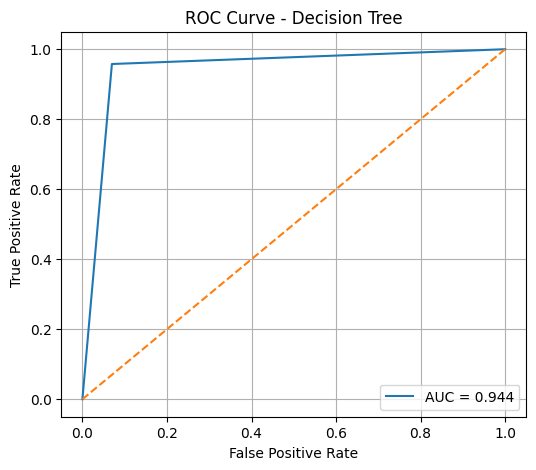

In [5]:

# Decision Tree
tree = DecisionTreeClassifier(random_state=42)

tree.fit(X_train,y_train)

y_pred_tree = tree.predict(X_test)

y_prob_tree = tree.predict_proba(X_test)[:,1]

print("========== Decision Tree ==========\n")

print("Accuracy :", accuracy_score(y_test,y_pred_tree))

print("\nPrecision :", precision_score(y_test,y_pred_tree))

print("Recall :", recall_score(y_test,y_pred_tree))

print("F1 Score :", f1_score(y_test,y_pred_tree))

print("\nClassification Report\n")

print(classification_report(y_test,y_pred_tree))

# Confusion Matrix


cm = confusion_matrix(y_test,y_pred_tree)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot(cmap="Greens")

plt.title("Decision Tree Confusion Matrix")

plt.show()


# ROC Curve


fpr,tpr,_ = roc_curve(y_test,y_prob_tree)

auc = roc_auc_score(y_test,y_prob_tree)

plt.figure(figsize=(6,5))

plt.plot(fpr,tpr,label=f"AUC = {auc:.3f}")

plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve - Decision Tree")

plt.legend()

plt.grid()

plt.show()

                 Model  Accuracy  Precision    Recall  F1 Score      AUC
0  Logistic Regression  0.973684   0.972222  0.985915  0.979021  0.99738
1        Decision Tree  0.947368   0.957746  0.957746  0.957746  0.94399


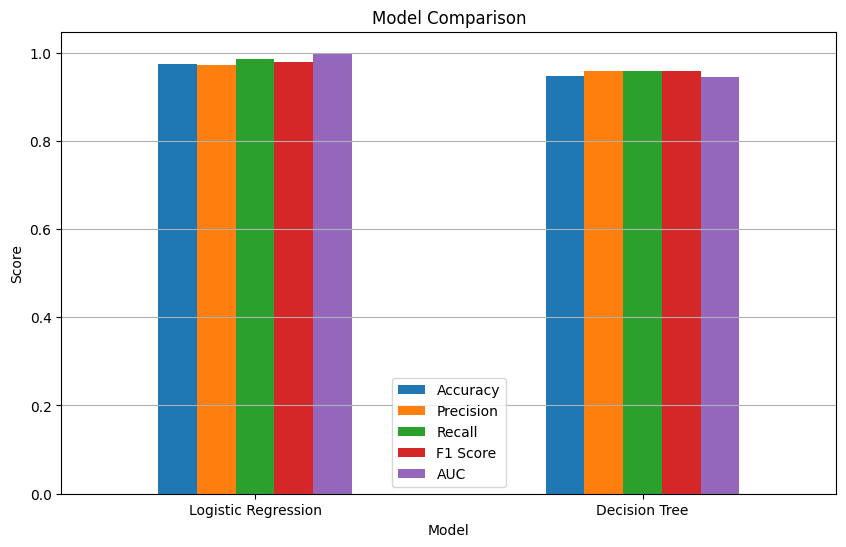

In [6]:

# Compare Models


comparison = pd.DataFrame({

    "Model":[
        "Logistic Regression",
        "Decision Tree"
    ],

    "Accuracy":[
        accuracy_score(y_test,y_pred_log),
        accuracy_score(y_test,y_pred_tree)
    ],

    "Precision":[
        precision_score(y_test,y_pred_log),
        precision_score(y_test,y_pred_tree)
    ],

    "Recall":[
        recall_score(y_test,y_pred_log),
        recall_score(y_test,y_pred_tree)
    ],

    "F1 Score":[
        f1_score(y_test,y_pred_log),
        f1_score(y_test,y_pred_tree)
    ],

    "AUC":[
        roc_auc_score(y_test,y_prob_log),
        roc_auc_score(y_test,y_prob_tree)
    ]

})

print(comparison)

comparison.set_index("Model").plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("Model Comparison")

plt.ylabel("Score")

plt.xticks(rotation=0)

plt.grid(axis='y')

plt.show()